<a href="https://colab.research.google.com/github/MachineLearning30110/MachineLearning-Models/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Linear Regression**

    y = w1​*x1​ + w2*​x2 ​+ ⋯ + wn*​xn ​+ b














In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


In [ ]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'target'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print(X_test.shape)

(2064, 8)


In [ ]:
y_test.describe()

,target
count,2064.000000
mean,2.068025
std,1.155100
min,0.300000
25%,1.191750
50%,1.807500
75%,2.644000
max,5.000010


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
preds = model.predict(X_test)

print(preds[:5])

[0.73044235 1.75506423 2.67574887 2.84668118 2.61213419]


In [ ]:
print("weights =",model.coef_) # w1, w2, w3, ... wn
print("bias =",model.intercept_) # b
print("Pred:", preds[:5])
print("Actual:", y_test.values[:5])

weights = [ 4.41643302e-01  9.57511565e-03 -1.10367141e-01  6.52574143e-01
 -4.32296453e-06 -3.61976686e-03 -4.18702648e-01 -4.31747018e-01]
bias = -36.71960336655723
Pred: [0.73044235 1.75506423 2.67574887 2.84668118 2.61213419]
Actual: [0.477   0.458   5.00001 2.186   2.78   ]


0.3
5.00001


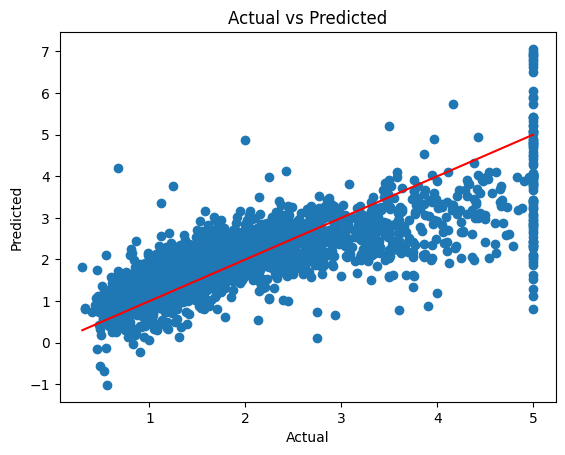

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red")

plt.show()

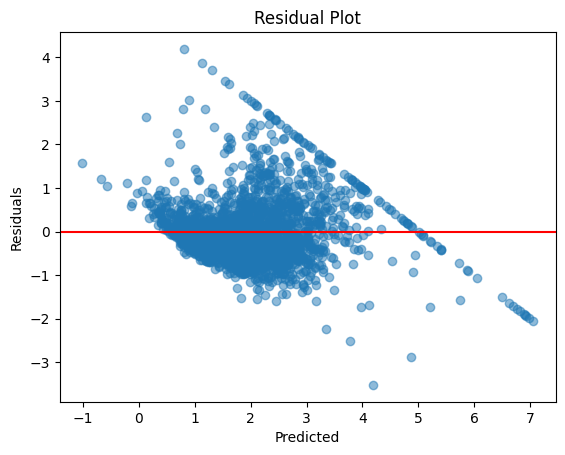

In [ ]:
residuals = y_test - preds

plt.scatter(preds, residuals, alpha=0.5)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.axhline(0,color="red")  # zero error line

plt.show()

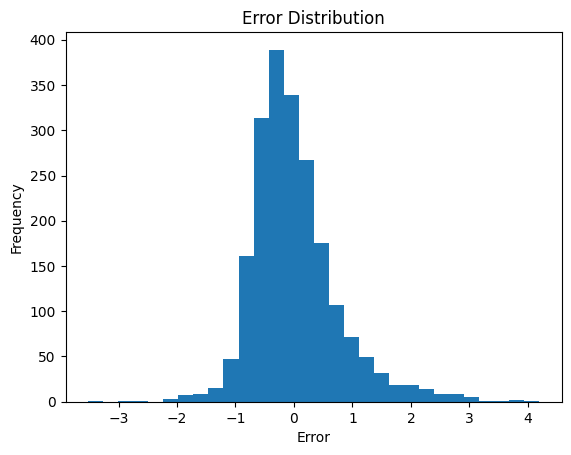

In [ ]:
plt.hist(residuals, bins=30)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()